In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
file = ""  # Enter your file path/folder path in this place
temperature = ""  # Enter your file path/folder path in this place
df = pd.read_csv(file)
temp_df = pd.read_csv(temperature)

In [80]:
#spectra_temp = np.array(df['temperature'])


In [81]:
time = np.array(df['timestamp(in Hour):'])
band_gap = np.array(df['band_gap'])
cycle_number = np.array(df['cycle_number_avg'])


In [82]:
df

,timestamp(in Hour):,band_gap,tauc_slope,tauc_slope_b,tauc_r2,tauc_rmse,window_start,window_end,cycle_number_avg,temperature,cycle
0,0.001759,1.533101,30.411520,-46.623920,0.925025,0.099960,1.562894,1.602688,0,19.53,1
1,0.038981,1.543437,33.872074,-52.279407,0.989415,0.040442,1.558768,1.598556,0,44.50,1
2,0.072315,1.546248,30.278335,-46.817827,0.972680,0.058449,1.581431,1.621127,0,56.74,1
3,0.105648,1.554308,33.191079,-51.589161,0.970970,0.066352,1.580222,1.620068,1,62.65,1
4,0.138981,1.555695,33.185865,-51.627074,0.986447,0.044950,1.579819,1.619645,1,65.92,1
...,...,...,...,...,...,...,...,...,...,...,...
1345,75.872407,1.552972,31.428805,-48.808059,0.990581,0.035332,1.586286,1.626016,49,67.94,50
1346,75.905833,1.554256,33.600662,-52.224041,0.980359,0.054972,1.580020,1.619856,49,66.35,50
1347,75.939167,1.552371,32.958326,-51.163536,0.974531,0.061490,1.578813,1.618588,50,64.72,50
1348,75.972593,1.551579,32.359300,-50.207995,0.975708,0.058956,1.579215,1.619010,50,64.54,50


In [83]:
error_bg = np.array(df["tauc_rmse"])/np.sqrt(3)/10

In [84]:
error_bg

array([0.0057712 , 0.00233492, 0.00337454, ..., 0.00355012, 0.00340381,
       0.00827982])

In [85]:
temp_df

,Timestamp,Elapsed_s,Temp_A_C,Setpoint_C,Phase,Orbit
0,2025-09-15T15:50:47.064804,0.043,20.052,19.98,sunlit,1
1,2025-09-15T15:50:47.093076,0.072,20.052,20.28,sunlit,1
2,2025-09-15T15:50:48.071960,1.050,20.056,20.57,sunlit,1
3,2025-09-15T15:50:49.070598,2.049,20.064,20.86,sunlit,1
4,2025-09-15T15:50:50.062904,3.041,20.077,21.15,sunlit,1
...,...,...,...,...,...,...
275995,2025-09-18T20:30:41.048687,275994.027,17.285,18.49,sunlit,50
275996,2025-09-18T20:30:42.053961,275995.032,17.608,18.79,sunlit,50
275997,2025-09-18T20:30:43.073417,275996.052,17.927,19.09,sunlit,50
275998,2025-09-18T20:30:44.079215,275997.058,18.277,19.39,sunlit,50


In [86]:
time_temperature = np.array(temp_df["Elapsed_s"]) / 3600
temperature = np.array(temp_df["Temp_A_C"])
orbit_temperature = np.array(temp_df["Orbit"])

In [87]:
mask = cycle_number < 2
mask_temp = orbit_temperature < 4
print(mask)
band_gap_selected = band_gap[mask]
time_selected = time[mask]
spectra_temp_selected = spectra_temp[mask]
error_bg_selected = error_bg[mask]
time_temp_selected = time_temperature[mask_temp]
temperature_selected = temperature[mask_temp]
orbit_temperature_selected = orbit_temperature[mask_temp]

[ True  True  True ... False False False]


In [88]:
len(time)
len(time_selected)

78

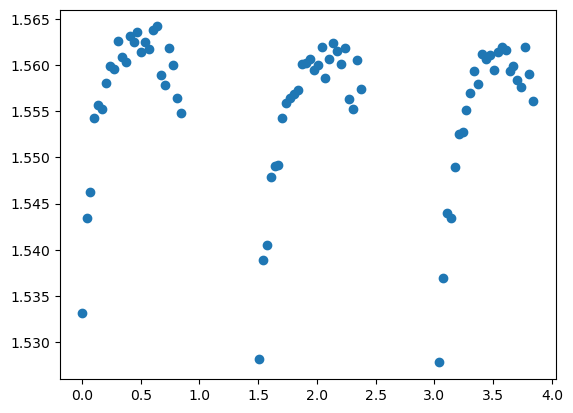

In [89]:
plt.scatter(time_selected, band_gap_selected)


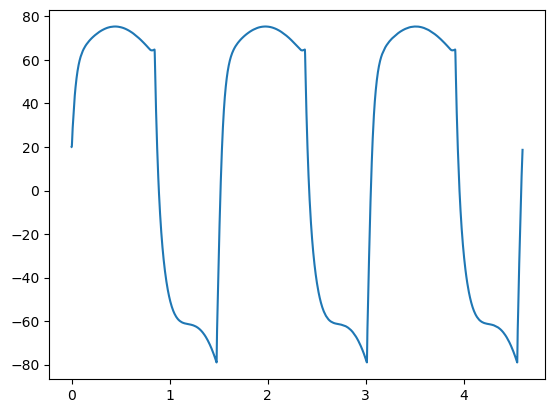

In [90]:
plt.plot(time_temp_selected, temperature_selected)

In [91]:
len(error_bg)

1350

In [92]:
len(band_gap_selected)

78

Text(0, 0.5, 'Temperature [$^\\circ$C]')

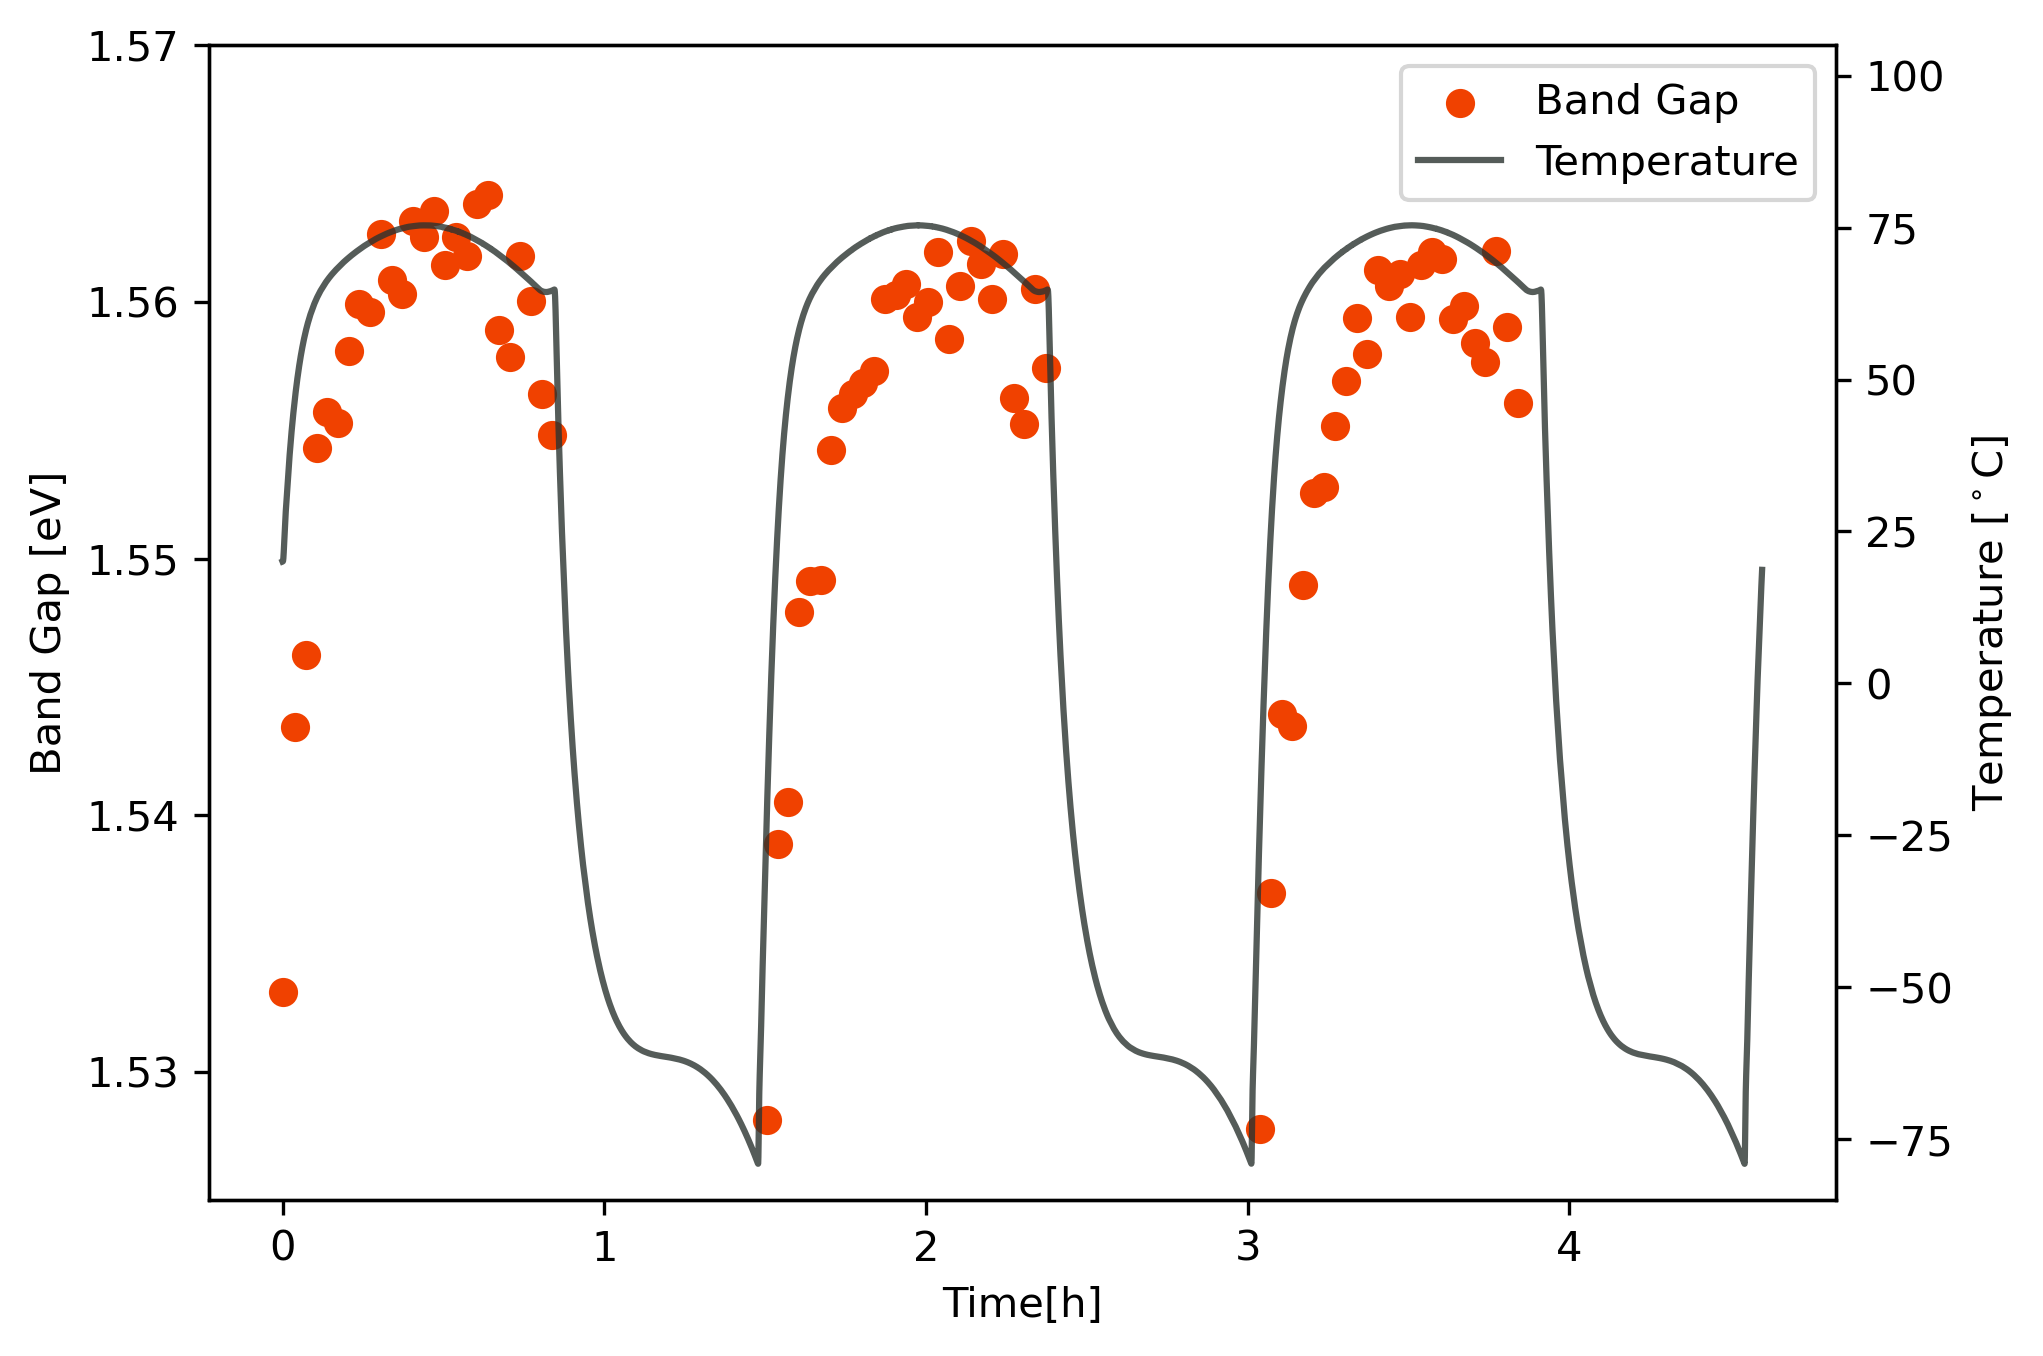

In [93]:
fig, ax1 = plt.subplots(figsize=(7, 5), dpi=300)
ax1.scatter(time_selected, band_gap_selected, label = "Band Gap", color = "#F04100")
ax1.set_ylim(1.525, 1.570)
ax1.set_xlabel("Time[h]")
ax1.set_ylabel("Band Gap [eV]")
ax2 = ax1.twinx()
ax2.plot(time_temp_selected, temperature_selected, color = "#2B3330", alpha = 0.8, label = "Temperature")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax2.set_ylim(-85, 105)
ax2.set_ylabel(r"Temperature [$^\circ$C]")


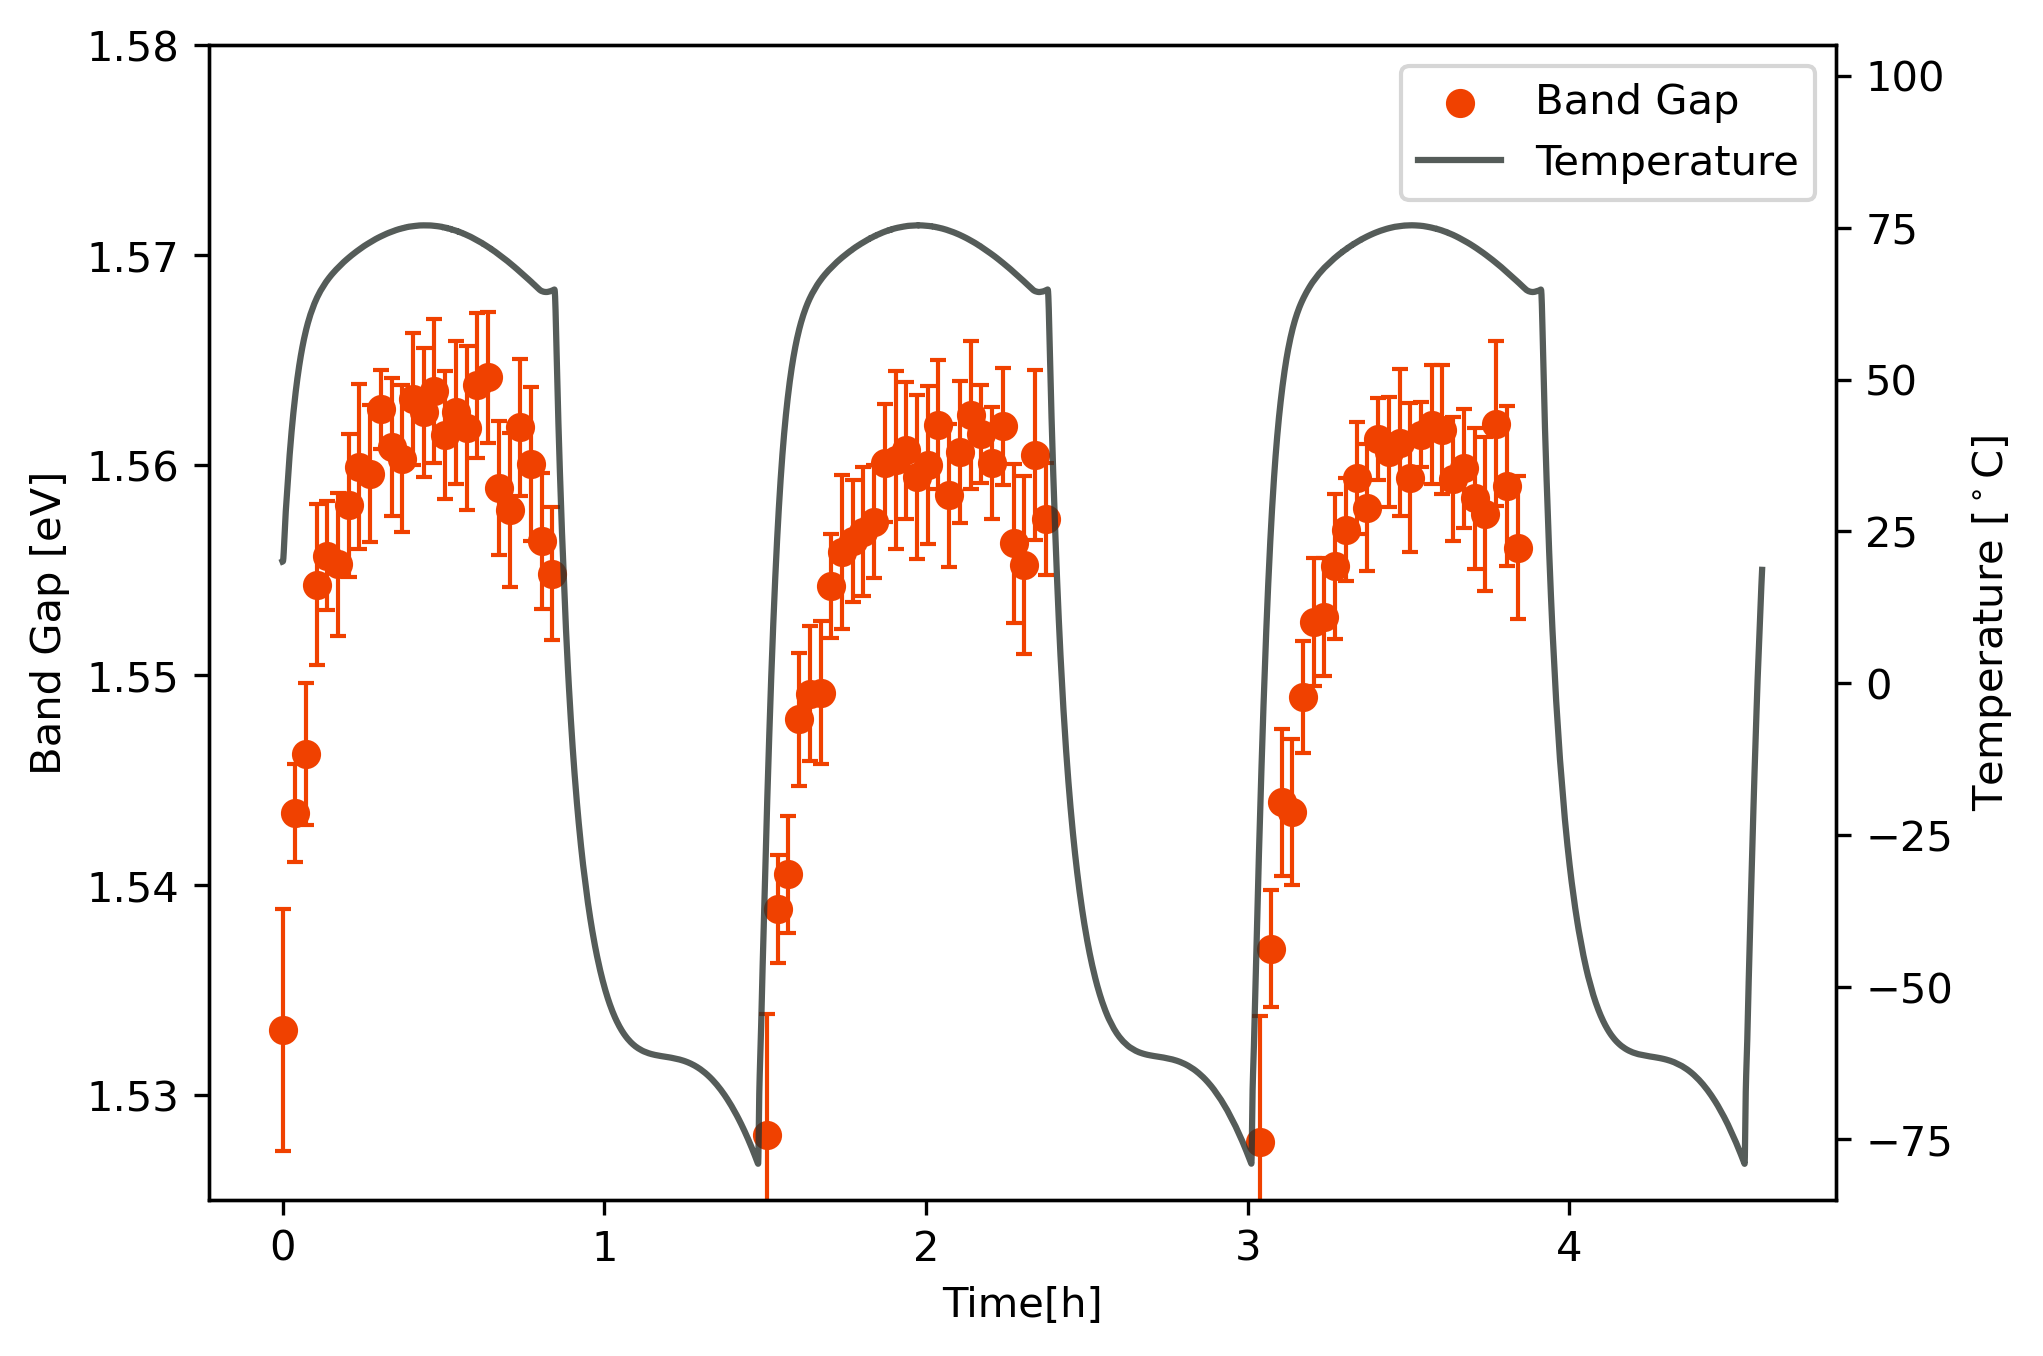

In [96]:
fig, ax1 = plt.subplots(figsize=(7, 5), dpi=300)

# Scatter plot
ax1.scatter(time_selected, band_gap_selected, label="Band Gap", color="#F04100")

# Add errorbar for band gap
ax1.errorbar(
    time_selected,
    band_gap_selected,
    yerr=error_bg_selected,
    fmt='none',           # no marker, keep scatter's marker
    ecolor="#F04100",     # same color as scatter
    elinewidth=1,
    capsize=2,
    #label="Band Gap Error"
)

ax1.set_ylim(1.525, 1.580)
ax1.set_xlabel("Time[h]")
ax1.set_ylabel("Band Gap [eV]")

# Temperature axis
ax2 = ax1.twinx()
ax2.plot(time_temp_selected, temperature_selected, color="#2B3330", alpha=0.8, label="Temperature")
ax2.set_ylim(-85, 105)
ax2.set_ylabel(r"Temperature [$^\circ$C]")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
